In [45]:
import pandas as pd 
import numpy as np 

In [46]:
df =  pd.read_csv("train.txt", header=None, names=['text', 'emotion'], sep=';')

In [47]:
df

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [48]:
emotion = {}
unique_emo = df['emotion'].unique()
i = 0
for emo in unique_emo: 
    emotion[emo] = i 
    i += 1

df['emotion'] = df['emotion'].map(emotion) # emotion into number



df['text'] = df['text'].apply(lambda x : x.lower()) 



import string 

def rem_punt(txt):
    return txt.translate(str.maketrans("","",string.punctuation)) 

df['text'] = df['text'].apply(rem_punt)



def rem_no(txt): 
    new = ""
    for i in txt:
        if not i.isdigit(): 
            new = new + i 
    return new 

df['text'] = df['text'].apply(rem_no)



from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_word = set(stopwords.words('english'))

def tokenization(txt): 
    texts = word_tokenize(txt)
    tokens = []

    for i in texts: 
        if i not in stop_word: 
            tokens.append(i)
    return " ".join(tokens)

df['text'] = df['text'].apply(tokenization)

In [49]:
df

,text,emotion
0,didnt feel humiliated,0
1,go feeling hopeless damned hopeful around some...,0
2,im grabbing minute post feel greedy wrong,1
3,ever feeling nostalgic fireplace know still pr...,2
4,feeling grouchy,1
...,...,...
15995,brief time beanbag said anna feel like beaten,0
15996,turning feel pathetic still waiting tables sub...,0
15997,feel strong good overall,5
15998,feel like rude comment im glad,1


There are three methods to convert a text into vectors(arrays)
1. one hot encoding - this method we don't use because it creates a too many columns and the dimension of the vectors will be different in every sentence and in machine learning it cannot be usable
2. Bag of words - In this the 1d vector is created and it stores data in 0 and 1
eg. 1. aman is playing
    2. anurag is playing
    3. jishan playing with anurag
   it first create a vector like ['aman', 'is', 'playing', 'anurag', 'jishan', 'with']
   now for 1. [1 1 1 0 0 0]
       for 2. [0 1 1 1 0 0]
       for 3. [0 0 1 1 1 1]

3. TF-IDF (term frequency - inverse document frequency) - this we can say the improve version of bag of word. In this method we use the formula for making vector on the basis of a word is repeating how many times acoording to it, a value is provided in the vector instead of 0 and 1 it uses value of term frequency

    fomula : 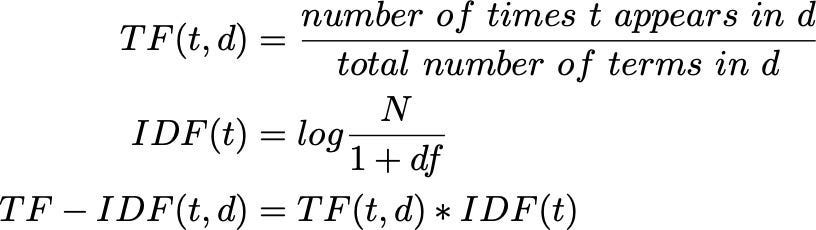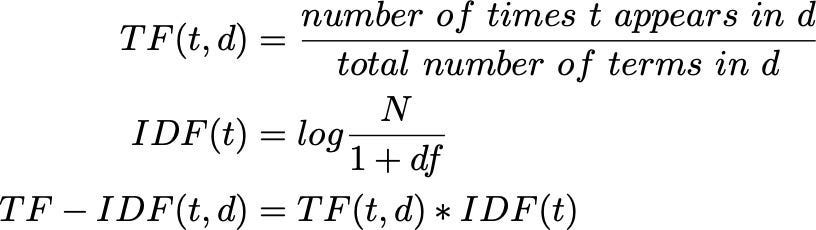

the vector values lies in between 0-1

In [50]:
# we can also use the library for data cleaning 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
# in nlp there is most useful algos are naive byes and svm and logistic regression

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [51]:
x = df['text']
y = df['emotion'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [52]:
x_train

676      refers course though cant help feeling somehow...
12113                im starting feel im suffering fatigue
7077     feel like probably would liked book little bit...
13005                                  really feel awkward
12123    im feeling little grumpy today lame weather te...
                               ...                        
13418    love leave reader feeling confused slightly de...
5390                                         feel delicate
860                          starting feel little stressed
15795             feel stressed tired worn shape neglected
7270         feel someone rude wrongly done something lose
Name: text, Length: 12800, dtype: object

In [53]:
# now converting the text into the vectors 
bow = CountVectorizer() #bag of word model for voectorization 

tf = TfidfVectorizer() # tf-idf model for vectorization 

bow_vec = bow.fit_transform(x_train)

tf_vec = tf.fit_transform(x_train)


test_bow_vec = bow.transform(x_test)
test_tf_vec = tf.transform(x_test)

In [62]:
naive = MultinomialNB()

naive_model_bow = naive.fit(bow_vec, y_train)
naive_model_tf = naive.fit(tf_vec, y_train)

res_bow = naive_model_bow.predict(test_bow_vec) 
print(res_bow)
print("bow score : ",naive_model_bow.score(test_bow_vec, y_test))

res_tf = naive_model_tf.predict(test_tf_vec)
print(res_tf)
print("tf-idf score : ",naive_model_tf.score(test_tf_vec, y_test))

[0 5 0 ... 5 5 0]
bow score :  0.675625
[0 5 0 ... 5 5 0]
tf-idf score :  0.6609375


In [63]:
log = LogisticRegression()

log_bow = log.fit(bow_vec, y_train)
log_tf = log.fit(tf_vec, y_train)

res_log_bow = log_bow.predict(test_bow_vec)
print(res_log_bow)
print("bow score : ", log_bow.score(test_bow_vec, y_test))

res_log_tf = log_tf.predict(test_tf_vec)
print(res_log_tf)
print("tf-idf score : ", log_tf.score(test_tf_vec, y_test))

[0 5 0 ... 5 5 0]
bow score :  0.848125
[0 5 0 ... 5 5 0]
tf-idf score :  0.8615625
